[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter2_lecture_notebook.ipynb)

# Modelling Financial Markets — Chapter 2: Market Efficiency, from EMH to Adaptive Markets

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

This notebook reproduces the main charts and tables of Lecture 2 (Sections 1–13 below) on real daily data: 13 equity indices (2000–2026), Bitcoin, Ethereum and EUR/RON. The case-study replication and the AI mini-case have their own code (Quantlet `MFM_ch2_big_data`).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_2'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [1]:
import io
import os
import re
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from scipy.special import gammaln
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [2]:
# Chart style: transparent background, legend below the plot
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Chart colours
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Navy     = '#1F2A44'   # reference lines (no grey in charts)
BandBlue = '#C5D2E8'   # light MainBlue tint for confidence / reference bands
Gray, LightGray = Navy, BandBlue   # legacy names kept for importing scripts
GROUP_COL = {'Developed': MainBlue, 'Emerging/frontier': IDAred, 'Crypto': Amber, 'FX': Forest}

SEED = 42
TABLE_DIR = '.'


def save_fig(name):
    """Save the figure as transparent PDF and PNG in the current folder."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Place the legend outside the plot, bottom centre."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)



import tempfile
KEEP = globals().get('SAVE_TO_DRIVE', False)   # switch from the Colab cell above
TABLE_DIR = globals().get('OUT_DIR', '.') if KEEP else tempfile.gettempdir()


def save_fig(name):
    """Show the figure; with SAVE_TO_DRIVE = True also save it (PDF and PNG) in OUT_DIR."""
    if KEEP:
        for ext in ('pdf', 'png'):
            plt.savefig(os.path.join(TABLE_DIR, f'{name}.{ext}'), bbox_inches='tight', transparent=True, dpi=200)
    plt.show()
    plt.close()

## Data

- Daily closes up to 18 September 2026.
- Equity indices: weekdays only; a close equal to the previous one is treated as a filled holiday and removed (this also drops the rare genuine zero-return day).
- Crypto trades 7 days a week; EUR/RON is the BNR official reference rate.
- Each series is analysed on its own calendar.

In [3]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# name -> (symbol, label, group, start date, days per year)
MARKETS = {
    'sp500':  ('GSPC.INDX',     'S&P 500 (US)',          'Developed', '2000-01-01', 252),
    'stoxx':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Developed', '2000-01-01', 252),
    'nikkei': ('N225.INDX',     'Nikkei 225 (Japan)',    'Developed', '2000-01-01', 252),
    'hsi':    ('HSI.INDX',      'Hang Seng (HK)',        'Developed', '2000-01-01', 252),
    'bet':    ('BET',           'BET (Romania)',         'Emerging/frontier', '2000-01-01', 252),
    'wig20':  ('WIG20.INDX',    'WIG20 (Poland)',        'Emerging/frontier', '2000-01-01', 252),
    'bux':    ('BUX.INDX',      'BUX (Hungary)',         'Emerging/frontier', '2000-01-01', 252),
    'px':     ('PX.INDX',       'PX (Czechia)',          'Emerging/frontier', '2000-01-01', 252),
    'xu100':  ('XU100.INDX',    'BIST 100 (Turkey)',     'Emerging/frontier', '2000-01-01', 252),
    'bvsp':   ('BVSP.INDX',     'Bovespa (Brazil)',      'Emerging/frontier', '2000-01-01', 252),
    'mxx':    ('MXX.INDX',      'IPC (Mexico)',          'Emerging/frontier', '2000-01-01', 252),
    'nsei':   ('NSEI.INDX',     'Nifty 50 (India)',      'Emerging/frontier', '2000-01-01', 252),
    'ssec':   ('SSEC.INDX',     'Shanghai (China)',      'Emerging/frontier', '2000-01-01', 252),
    'btc':    ('BTC-USD.CC',    'Bitcoin',               'Crypto', '2014-09-17', 365),
    'eth':    ('ETH-USD.CC',    'Ethereum',              'Crypto', '2016-01-01', 365),
    'eurron': ('REF:EUR',       'EUR/RON (reference rate)', 'FX', '2005-07-01', 252),
}

LABELS = {k: v[1] for k, v in MARKETS.items()}
GROUPS = {k: v[2] for k, v in MARKETS.items()}
PERIODS = {k: v[4] for k, v in MARKETS.items()}

_CACHE = {}


def read_market(symbol):
    """Daily price table of one series (local copy of the course data, otherwise the GitHub repository)."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official RON reference rate (BNR annual XML archives)."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(int(start[:4]), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}">([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END):
    """Daily closing price, cleaned with the chapter conventions."""
    symbol, _, group, start0, _ = MARKETS[name]
    start = start or start0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    s = read_market(symbol)['close'].loc[start:end]
    s = s[s > 0].dropna()
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    return s.rename(name)


def complete_months(x):
    """Drop the incomplete final month (last observation before the last business day of the month):
    the monthly analyses and the turn-of-the-month effect use complete months only."""
    last = x.index[-1]
    if last + pd.offsets.BMonthEnd(0) != last:
        x = x[x.index < last.to_period('M').start_time]
    return x


def log_returns(name, start=None, end=END):
    """Log returns on the series' own calendar."""
    return np.log(load_close(name, start, end)).diff().dropna().rename(name)


rets = {k: log_returns(k) for k in MARKETS}
ORDER = list(MARKETS)
for k in ORDER:
    print(f'{LABELS[k]:26s}', rets[k].index[0].date(), '->', rets[k].index[-1].date(), len(rets[k]), 'obs')

S&P 500 (US)               2000-01-04 -> 2026-09-18 6714 obs
Euro Stoxx 50              2000-01-04 -> 2026-09-18 6836 obs
Nikkei 225 (Japan)         2000-01-05 -> 2026-09-18 6545 obs
Hang Seng (HK)             2000-01-04 -> 2026-09-18 6583 obs
BET (Romania)              2000-01-06 -> 2026-09-18 6670 obs
WIG20 (Poland)             2000-01-04 -> 2026-09-18 6685 obs
BUX (Hungary)              2000-01-05 -> 2026-09-18 6666 obs
PX (Czechia)               2000-01-06 -> 2026-09-18 6682 obs
BIST 100 (Turkey)          2000-01-05 -> 2026-09-18 6692 obs
Bovespa (Brazil)           2000-01-04 -> 2026-09-18 6622 obs
IPC (Mexico)               2000-01-04 -> 2026-09-18 6689 obs
Nifty 50 (India)           2000-01-04 -> 2026-09-18 6606 obs
Shanghai (China)           2000-01-05 -> 2026-09-18 6474 obs
Bitcoin                    2014-09-18 -> 2026-09-18 4384 obs
Ethereum                   2016-01-02 -> 2026-09-18 3913 obs
EUR/RON (reference rate)   2005-07-05 -> 2026-09-18 5352 obs


## Efficiency tests

- `variance_ratio`: Lo–MacKinlay VR(q) with the homoskedastic $z$ and the robust $z^*$.
- `chow_denning`, `runs_test`, `robust_ljung_box`, `rs_hurst` (with Anis–Lloyd), `lo_modified_rs`, `dfa_hurst`, `rolling_stat`.

In [4]:
def variance_ratio(r, q):
    """Overlapping VR(q) with the Lo-MacKinlay (1988) bias corrections.

    Returns (VR, homoskedastic z, heteroskedasticity-robust z*).
    """
    x = np.asarray(r, dtype=float)
    T = len(x)
    mu = x.mean()
    e = x - mu
    var_a = (e ** 2).sum() / (T - 1)
    agg = np.convolve(x, np.ones(q), mode='valid') - q * mu        # overlapping q-period sums
    m = q * (T - q + 1) * (1 - q / T)
    var_c = (agg ** 2).sum() / m
    vr = var_c / var_a
    z_homo = (vr - 1) / np.sqrt(2 * (2 * q - 1) * (q - 1) / (3 * q * T))
    den = (e ** 2).sum() ** 2
    theta = 0.0
    for j in range(1, q):
        delta = T * (e[j:] ** 2 * e[:-j] ** 2).sum() / den
        theta += (2 * (q - j) / q) ** 2 * delta
    z_star = np.sqrt(T) * (vr - 1) / np.sqrt(theta)
    return vr, z_homo, z_star


def chow_denning(r, qs=(2, 5, 10, 20)):
    """Chow-Denning multiple test: max |z*(q)|; p-value from the studentized maximum modulus (infinite df)."""
    zs = [variance_ratio(r, q)[2] for q in qs]
    zmax = np.max(np.abs(zs))
    p = 1 - (2 * stats.norm.cdf(zmax) - 1) ** len(qs)
    return zmax, p, zs


def runs_test(r):
    """Number of sign runs (zeros dropped), with its mean and variance under independence."""
    s = np.sign(np.asarray(r, dtype=float))
    s = s[s != 0]
    n1, n2 = (s > 0).sum(), (s < 0).sum()
    n = n1 + n2
    runs = 1 + (s[1:] != s[:-1]).sum()
    mean = 2 * n1 * n2 / n + 1
    var = 2 * n1 * n2 * (2 * n1 * n2 - n) / (n ** 2 * (n - 1))
    z = (runs - mean) / np.sqrt(var)
    return runs, mean, z, 2 * (1 - stats.norm.cdf(abs(z)))


def robust_ljung_box(r, m=10):
    """Ljung-Box Q(m) and Q~(m) with the robust variance tau_k = sum e_t^2 e_{t-k}^2 / (sum e_t^2)^2."""
    e = np.asarray(r, dtype=float) - np.mean(r)
    T = len(e)
    s2 = (e ** 2).sum()
    q_lb, q_rob = 0.0, 0.0
    for k in range(1, m + 1):
        rho = (e[k:] * e[:-k]).sum() / s2
        tau = (e[k:] ** 2 * e[:-k] ** 2).sum() / s2 ** 2
        q_lb += T * (T + 2) * rho ** 2 / (T - k)
        q_rob += rho ** 2 / tau
    return q_lb, 1 - stats.chi2.cdf(q_lb, m), q_rob, 1 - stats.chi2.cdf(q_rob, m)


def _rs(x):
    y = np.cumsum(x - x.mean())
    s = x.std(ddof=0)
    return (y.max() - y.min()) / s if s > 0 else np.nan


def expected_rs(n):
    """E[R/S] for i.i.d. noise (Anis & Lloyd, 1976)."""
    if n <= 340:
        f = np.exp(gammaln((n - 1) / 2) - gammaln(n / 2)) / np.sqrt(np.pi)
    else:
        f = 1 / np.sqrt(n * np.pi / 2)
    i = np.arange(1, n)
    return f * np.sum(np.sqrt((n - i) / i))


def rs_hurst(r, min_n=10, n_sizes=20):
    """H from the slope of log(R/S) on log(n) (Hurst, 1951) and the Anis-Lloyd corrected H (slope of R/S - E[R/S], plus 0.5)."""
    x = np.asarray(r, dtype=float)
    T = len(x)
    sizes = np.unique(np.logspace(np.log10(min_n), np.log10(T // 4), n_sizes).astype(int))
    rs, ers = [], []
    for n in sizes:
        k = T // n
        vals = [_rs(x[i * n:(i + 1) * n]) for i in range(k)]
        rs.append(np.nanmean(vals))
        ers.append(expected_rs(n))
    ls, lrs, lers = np.log(sizes), np.log(rs), np.log(ers)
    h = np.polyfit(ls, lrs, 1)[0]
    h_al = 0.5 + np.polyfit(ls, lrs - lers, 1)[0]
    return h, h_al, pd.DataFrame({'n': sizes, 'rs': rs, 'expected_rs': ers})


def lo_modified_rs(r, q=None):
    """Lo's (1991) statistic V = Q_T / sqrt(T); under H0 (no long memory) V lies in [0.809, 1.862] with 95% probability."""
    x = np.asarray(r, dtype=float)
    T = len(x)
    e = x - x.mean()
    if q is None:                                   # Andrews (1991) bandwidth for an AR(1)
        rho = np.corrcoef(e[1:], e[:-1])[0, 1]
        q = int(np.floor((3 * T / 2) ** (1 / 3) * abs(2 * rho / (1 - rho ** 2)) ** (2 / 3)))
    s2 = (e ** 2).mean()
    for j in range(1, q + 1):
        w = 1 - j / (q + 1)
        s2 += 2 * w * (e[j:] * e[:-j]).sum() / T
    y = np.cumsum(e)
    Q = (y.max() - y.min()) / np.sqrt(s2)
    return Q / np.sqrt(T), q


def dfa_hurst(r, min_box=10, n_sizes=18, max_frac=0.25):
    """DFA-1 exponent: slope of log F(n) on log n for the cumulative profile of demeaned returns."""
    x = np.asarray(r, dtype=float)
    y = np.cumsum(x - x.mean())
    T = len(y)
    sizes = np.unique(np.logspace(np.log10(min_box), np.log10(int(T * max_frac)), n_sizes).astype(int))
    F = []
    for n in sizes:
        k = T // n
        seg = y[:k * n].reshape(k, n)
        t = np.arange(n)
        A = np.vstack([t, np.ones(n)]).T
        coef, *_ = np.linalg.lstsq(A, seg.T, rcond=None)
        resid = seg.T - A @ coef
        F.append(np.sqrt((resid ** 2).mean()))
    return np.polyfit(np.log(sizes), np.log(F), 1)[0], pd.DataFrame({'n': sizes, 'F': F})


def rolling_stat(r, func, window=500, step=21):
    """Apply func on rolling windows of `window` observations, every `step` observations."""
    x = r.values
    idx, out = [], []
    for end in range(window, len(x) + 1, step):
        idx.append(r.index[end - 1])
        out.append(func(x[end - window:end]))
    return pd.Series(out, index=idx)

## 1. Which series is the real market?

- One panel is the S&P 500 (2010–2026); three are random walks with the same drift and volatility (Roberts, 1959).

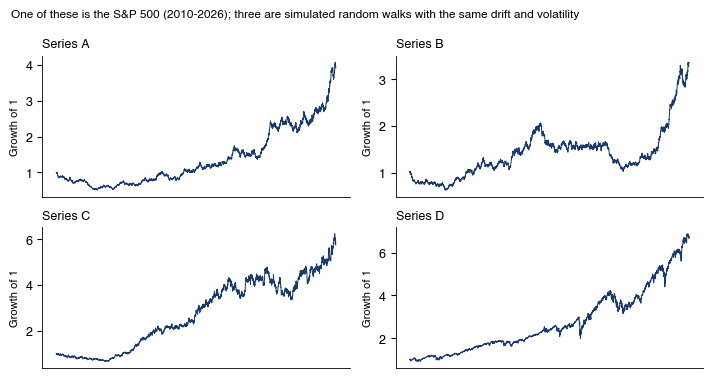

The real series is D


In [5]:
def fig_random_walk_game(seed=7):
    """S&P 500 2010-2026 among three random walks with the same drift and volatility."""
    p = load_close('sp500', start='2010-01-01')
    r = np.log(p).diff().dropna()
    rng = np.random.default_rng(seed)
    real_pos = rng.integers(0, 4)
    fig, axes = plt.subplots(2, 2, figsize=(7.2, 3.8), sharex=True)
    for i, ax in enumerate(axes.flat):
        if i == real_pos:
            path = np.log(p.values / p.values[0])
        else:
            sim = rng.normal(r.mean(), r.std(), len(r))
            path = np.concatenate([[0], np.cumsum(sim)])
        ax.plot(np.arange(len(path)), np.exp(path), color=MainBlue, lw=0.7)
        ax.set_title(f'Series {"ABCD"[i]}', fontsize=9, loc='left')
        ax.set_xticks([])
        ax.set_ylabel('Growth of 1', fontsize=8)
    fig.suptitle('One of these is the S&P 500 (2010-2026); three are simulated random walks with the same drift and volatility',
                 fontsize=8.5, x=0.02, ha='left')
    plt.tight_layout()
    save_fig('ch2_random_walk_game')
    pd.Series({'real_series': 'ABCD'[real_pos]}).to_csv(os.path.join(TABLE_DIR, 'ch2_random_walk_game_answer.csv'))
    return 'ABCD'[real_pos]


answer = fig_random_walk_game()
print('The real series is', answer)

## 2. Weak-form tests on 16 series

- $\hat\rho_1$ with i.i.d. and robust standard errors, VR(q) with $z$ and $z^*$, Chow–Denning, runs, Ljung–Box $Q(10)$ and robust $\tilde Q(10)$, R/S Hurst (raw and Anis–Lloyd), Lo's $V$ and DFA.

In [6]:
def efficiency_table():
    rows = []
    for k in ORDER:
        r = rets[k]
        e = r - r.mean()
        tau1 = (e.values[1:] ** 2 * e.values[:-1] ** 2).sum() / (e ** 2).sum() ** 2
        v2, v5, v10, v20 = (variance_ratio(r, q) for q in (2, 5, 10, 20))
        cd = chow_denning(r)
        rt = runs_test(r)
        lb = robust_ljung_box(r, 10)
        h, h_al, _ = rs_hurst(r)
        V, qv = lo_modified_rs(r)
        hd, _ = dfa_hurst(r)
        rows.append(dict(market=LABELS[k], group=GROUPS[k], start=r.index[0].date(), end=r.index[-1].date(),
                         N=len(r), rho1=r.autocorr(1), rho1_se_iid=1 / np.sqrt(len(r)), rho1_se_rob=np.sqrt(tau1),
                         VR2=v2[0], z2=v2[1], zstar2=v2[2], VR5=v5[0], z5=v5[1], zstar5=v5[2],
                         VR10=v10[0], zstar10=v10[2], VR20=v20[0], zstar20=v20[2],
                         CD=cd[0], CD_p=cd[1], runs_z=rt[2], runs_p=rt[3],
                         Q10=lb[0], Q10_p=lb[1], Q10rob=lb[2], Q10rob_p=lb[3],
                         H_rs=h, H_anis_lloyd=h_al, LoV=V, LoV_q=qv, H_dfa=hd))
    t = pd.DataFrame(rows, index=ORDER)
    t.to_csv(os.path.join(TABLE_DIR, 'ch2_efficiency_table.csv'), float_format='%.6g')
    return t


t = efficiency_table()
t.round(3).T

,sp500,stoxx,nikkei,hsi,bet,wig20,bux,px,xu100,bvsp,mxx,nsei,ssec,btc,eth,eurron
market,S&P 500 (US),Euro Stoxx 50,Nikkei 225 (Japan),Hang Seng (HK),BET (Romania),WIG20 (Poland),BUX (Hungary),PX (Czechia),BIST 100 (Turkey),Bovespa (Brazil),IPC (Mexico),Nifty 50 (India),Shanghai (China),Bitcoin,Ethereum,EUR/RON (reference rate)
group,Developed,Developed,Developed,Developed,Emerging/frontier,Emerging/frontier,Emerging/frontier,Emerging/frontier,Emerging/frontier,Emerging/frontier,Emerging/frontier,Emerging/frontier,Emerging/frontier,Crypto,Crypto,FX
start,2000-01-04,2000-01-04,2000-01-05,2000-01-04,2000-01-06,2000-01-04,2000-01-05,2000-01-06,2000-01-05,2000-01-04,2000-01-04,2000-01-04,2000-01-05,2014-09-18,2016-01-02,2005-07-05
end,2026-09-18,2026-09-18,2026-09-18,2026-09-18,2026-09-18,2026-09-18,2026-09-18,2026-09-18,2026-09-18,2026-09-18,2026-09-18,2026-09-18,2026-09-18,2026-09-18,2026-09-18,2026-09-18
N,6714,6836,6545,6583,6670,6685,6666,6682,6692,6622,6689,6606,6474,4384,3913,5352
rho1,-0.099,-0.029,-0.038,-0.004,0.109,0.018,0.037,0.052,0.005,-0.028,0.07,0.048,0.021,-0.022,-0.012,0.17
rho1_se_iid,0.012,0.012,0.012,0.012,0.012,0.012,0.012,0.012,0.012,0.012,0.012,0.012,0.012,0.015,0.016,0.014
rho1_se_rob,0.027,0.019,0.024,0.024,0.028,0.018,0.024,0.032,0.024,0.025,0.019,0.024,0.019,0.026,0.027,0.036
VR2,0.901,0.97,0.962,0.996,1.108,1.018,1.037,1.052,1.005,0.971,1.068,1.048,1.021,0.977,0.988,1.17
z2,-8.12,-2.444,-3.038,-0.332,8.827,1.469,3.008,4.215,0.386,-2.385,5.597,3.938,1.715,-1.503,-0.73,12.447


## 3. Lag-1 autocorrelation across markets

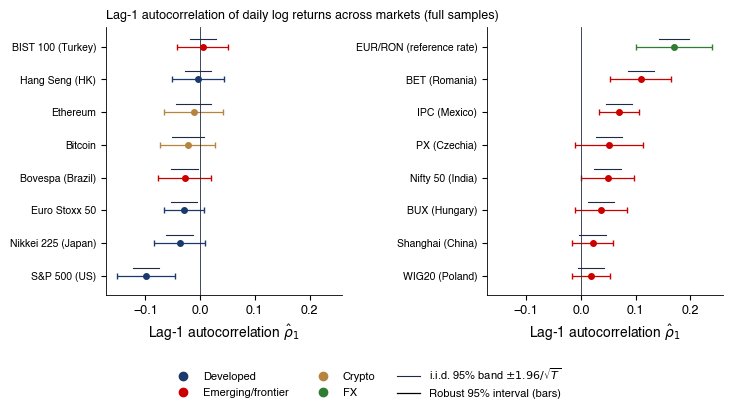

In [7]:
def _two_columns(n, figsize=(7.4, 3.6)):
    """Two panels side by side for a long list of markets (rows 0..h-1 left, h..n-1 right), shared x axis, so
    that the market names stay legible on a slide."""
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharex=True)
    h = (n + 1) // 2
    return fig, axes, [range(0, h), range(h, n)], h


def fig_acf_markets(t):
    t = t.sort_values('rho1')
    fig, axes, parts, h = _two_columns(len(t))
    for ax, idx in zip(axes, parts):
        for j, i in enumerate(idx):
            row = t.iloc[i]
            c = GROUP_COL[row['group']]
            ax.errorbar(row['rho1'], j, xerr=1.96 * row['rho1_se_rob'], fmt='o', ms=4, color=c, capsize=2, lw=0.9)
            ax.plot([row['rho1'] - 1.96 * row['rho1_se_iid'], row['rho1'] + 1.96 * row['rho1_se_iid']], [j + 0.25] * 2,
                    color=Gray, lw=0.8)
        ax.axvline(0, color=Gray, lw=0.6)
        ax.set_yticks(range(len(idx)), [t['market'].iloc[i] for i in idx], fontsize=7.5)
        ax.set_ylim(-0.6, h - 0.4)
        ax.set_xlabel(r'Lag-1 autocorrelation $\hat\rho_1$')
    handles = [plt.Line2D([], [], color=c, marker='o', ls='', label=g) for g, c in GROUP_COL.items()]
    handles += [plt.Line2D([], [], color=Gray, lw=0.8, label=r'i.i.d. 95% band $\pm 1.96/\sqrt{T}$'),
                plt.Line2D([], [], color='k', lw=0.9, label='Robust 95% interval (bars)')]
    axes[0].set_title('Lag-1 autocorrelation of daily log returns across markets (full samples)', fontsize=9, loc='left')
    plt.tight_layout()
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=3, frameon=False)
    save_fig('ch2_acf_markets')


fig_acf_markets(t)

## 4. Runs test

- Too few runs ($z < 0$): persistence of signs; too many ($z > 0$): sign reversals. Zero returns are dropped.

In [8]:
t[['market', 'rho1', 'runs_z', 'runs_p']].round(3)

,market,rho1,runs_z,runs_p
sp500,S&P 500 (US),-0.099,4.335,0.000
stoxx,Euro Stoxx 50,-0.029,3.409,0.001
nikkei,Nikkei 225 (Japan),-0.038,1.972,0.049
hsi,Hang Seng (HK),-0.004,-0.167,0.867
bet,BET (Romania),0.109,-6.051,0.000
wig20,WIG20 (Poland),0.018,2.246,0.025
bux,BUX (Hungary),0.037,-0.418,0.676
px,PX (Czechia),0.052,-2.525,0.012
xu100,BIST 100 (Turkey),0.005,-0.630,0.529
bvsp,Bovespa (Brazil),-0.028,0.875,0.381


## 5. Variance ratios

- $\text{VR}(q) = 1 + 2\sum_{k<q}(1 - k/q)\rho_k$; the robust band uses $\hat\theta(q)$ of Lo and MacKinlay (1988).

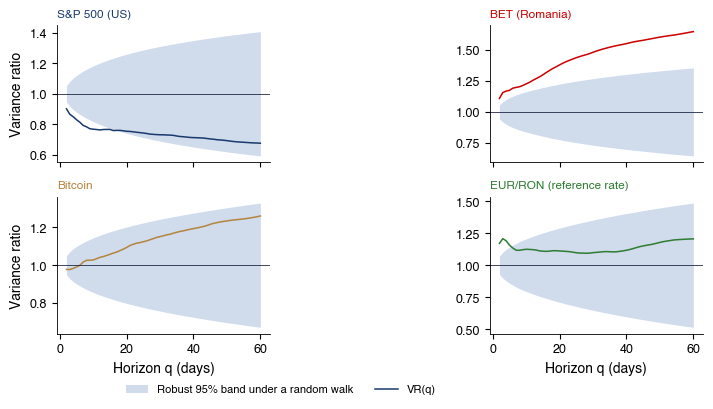

S&P 500 (US) {2: 0.901, 5: 0.83, 10: 0.767, 20: 0.753, 60: 0.674}
BET (Romania) {2: 1.108, 5: 1.173, 10: 1.225, 20: 1.377, 60: 1.644}
Bitcoin {2: 0.977, 5: 0.991, 10: 1.027, 20: 1.094, 60: 1.261}
EUR/RON (reference rate) {2: 1.17, 5: 1.157, 10: 1.124, 20: 1.111, 60: 1.205}


In [9]:
def vr_profile(r, qmax=60):
    out = []
    x = np.asarray(r, dtype=float)
    T = len(x)
    e = x - x.mean()
    den = (e ** 2).sum() ** 2
    deltas = np.array([T * (e[j:] ** 2 * e[:-j] ** 2).sum() / den for j in range(1, qmax)])
    for q in range(2, qmax + 1):
        vr = variance_ratio(r, q)[0]
        j = np.arange(1, q)
        theta = np.sum((2 * (q - j) / q) ** 2 * deltas[:q - 1])
        out.append((q, vr, 1.96 * np.sqrt(theta / T)))
    return pd.DataFrame(out, columns=['q', 'VR', 'band']).set_index('q')


def fig_vr_profile():
    sel = [('sp500', MainBlue), ('bet', IDAred), ('btc', Amber), ('eurron', Forest)]
    fig, axes = plt.subplots(2, 2, figsize=(7.2, 4.2), sharex=True)
    res = {}
    for ax, (k, c) in zip(axes.flat, sel):
        vp = vr_profile(rets[k])
        res[k] = vp
        ax.fill_between(vp.index, 1 - vp['band'], 1 + vp['band'], color=LightGray, alpha=0.8, lw=0,
                        label='Robust 95% band under a random walk')
        ax.plot(vp.index, vp['VR'], color=c, lw=1.1, label='VR(q)')
        ax.axhline(1, color=Gray, lw=0.6)
        ax.set_title(LABELS[k], fontsize=8.5, loc='left', color=c)
    for ax in axes[1]:
        ax.set_xlabel('Horizon q (days)')
    for ax in axes[:, 0]:
        ax.set_ylabel('Variance ratio')
    h, l = axes[0, 0].get_legend_handles_labels()
    axes[1, 0].legend(h, l, loc='upper center', bbox_to_anchor=(1.05, -0.3), ncol=2, frameon=False)
    plt.tight_layout()
    save_fig('ch2_vr_profile')
    return {k: v.loc[[2, 5, 10, 20, 60]] for k, v in res.items()}


for k, v in fig_vr_profile().items():
    print(LABELS[k], v['VR'].round(3).to_dict())

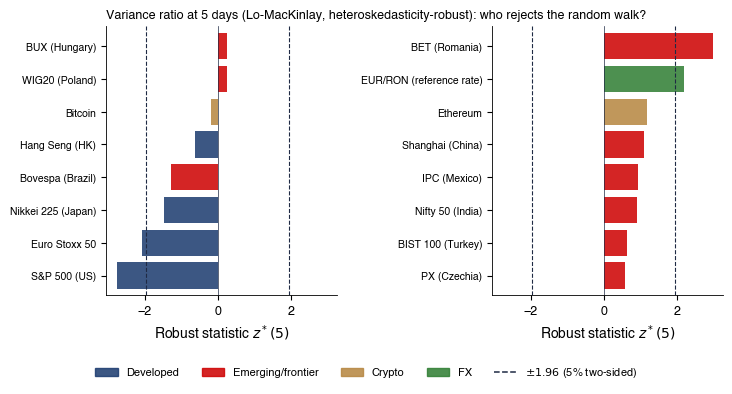

,market,zstar2,zstar5,zstar20,CD,CD_p
sp500,S&P 500 (US),-3.644,-2.772,-1.856,3.644,0.001
stoxx,Euro Stoxx 50,-1.574,-2.083,-1.952,2.238,0.097
nikkei,Nikkei 225 (Japan),-1.563,-1.485,-1.361,1.691,0.317
hsi,Hang Seng (HK),-0.170,-0.635,-0.826,0.839,0.872
bet,BET (Romania),3.836,2.980,3.311,3.836,0.001
wig20,WIG20 (Poland),1.010,0.241,0.174,1.010,0.777
bux,BUX (Hungary),1.514,0.257,0.142,1.514,0.427
px,PX (Czechia),1.634,0.592,0.974,1.634,0.350
xu100,BIST 100 (Turkey),0.198,0.637,0.624,0.637,0.949
bvsp,Bovespa (Brazil),-1.181,-1.285,-0.549,1.378,0.521


In [10]:
def fig_vr_markets(t):
    t = t.sort_values('zstar5')
    fig, axes, parts, h = _two_columns(len(t))
    for ax, idx in zip(axes, parts):
        tt = t.iloc[list(idx)]
        ax.barh(np.arange(len(tt)), tt['zstar5'], color=[GROUP_COL[g] for g in tt['group']], alpha=0.85)
        for x in (-1.96, 1.96):
            ax.axvline(x, color=Gray, ls='--', lw=0.8)
        ax.axvline(0, color=Gray, lw=0.5)
        ax.set_yticks(np.arange(len(tt)), tt['market'], fontsize=7.5)
        ax.set_ylim(-0.6, h - 0.4)
        ax.set_xlabel(r'Robust statistic $z^*(5)$')
    handles = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.85, label=g) for g, c in GROUP_COL.items()]
    handles.append(plt.Line2D([], [], color=Gray, ls='--', label=r'$\pm 1.96$ (5% two-sided)'))
    axes[0].set_title('Variance ratio at 5 days (Lo-MacKinlay, heteroskedasticity-robust): who rejects the random walk?',
                      fontsize=9, loc='left')
    plt.tight_layout()
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=5, frameon=False)
    save_fig('ch2_vr_markets')


fig_vr_markets(t)
t[['market', 'zstar2', 'zstar5', 'zstar20', 'CD', 'CD_p']].round(3)

## 6. Long memory: R/S and DFA

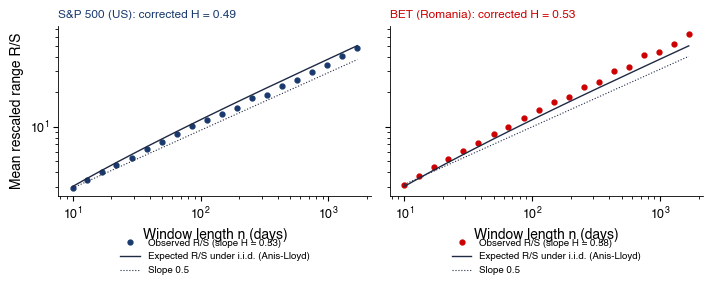

{'sp500': (np.float64(0.5304720271599295), np.float64(0.4855126734493656)),
 'bet': (np.float64(0.5781080117149741), np.float64(0.533110603511195))}

In [11]:
def fig_hurst_rs():
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.1), sharey=True)
    out = {}
    for ax, (k, c) in zip(axes, [('sp500', MainBlue), ('bet', IDAred)]):
        h, h_al, d = rs_hurst(rets[k])
        out[k] = (h, h_al)
        ax.loglog(d['n'], d['rs'], 'o', ms=3.5, color=c, label=f'Observed R/S (slope H = {h:.2f})')
        ax.loglog(d['n'], d['expected_rs'], '-', color=Gray, lw=1, label='Expected R/S under i.i.d. (Anis-Lloyd)')
        ax.loglog(d['n'], d['rs'].iloc[0] * (d['n'] / d['n'].iloc[0]) ** 0.5, ':', color=Gray, lw=0.8,
                  label='Slope 0.5')
        ax.set_xlabel('Window length n (days)')
        ax.set_title(f'{LABELS[k]}: corrected H = {h_al:.2f}', fontsize=8.5, loc='left', color=c)
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=1, frameon=False, fontsize=7)
    axes[0].set_ylabel('Mean rescaled range R/S')
    plt.tight_layout()
    save_fig('ch2_hurst_rs')
    return out


fig_hurst_rs()

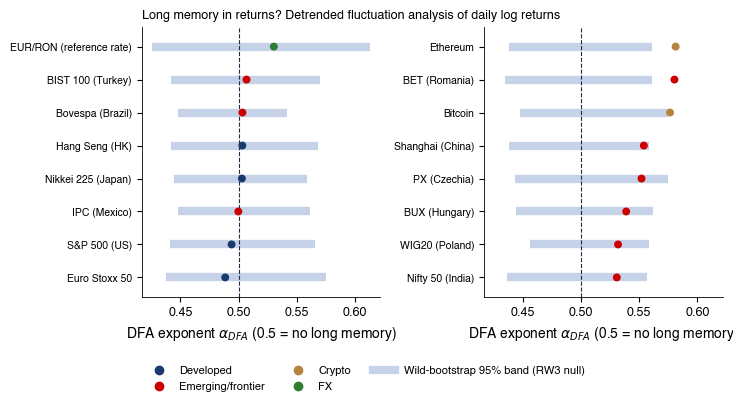

,H_dfa,band_lo,band_hi,shuf_lo,shuf_hi
stoxx,0.488,0.437,0.575,0.452,0.549
sp500,0.494,0.441,0.565,0.451,0.537
mxx,0.500,0.448,0.561,0.446,0.546
nikkei,0.503,0.444,0.559,0.455,0.546
hsi,0.503,0.442,0.568,0.452,0.536
bvsp,0.503,0.448,0.542,0.451,0.546
xu100,0.507,0.442,0.570,0.458,0.536
eurron,0.530,0.426,0.613,0.453,0.550
nsei,0.531,0.436,0.557,0.450,0.535
wig20,0.532,0.456,0.558,0.457,0.544


In [12]:
def shuffle_band(r, func, n_sim=200, seed=SEED):
    """95% band from permutations: destroys ALL dependence (including volatility clustering)."""
    rng = np.random.default_rng(seed)
    x = np.asarray(r, dtype=float)
    sims = [func(rng.permutation(x)) for _ in range(n_sim)]
    return np.percentile(sims, [2.5, 97.5])


def wild_band(r, func, n_sim=199, seed=SEED):
    """95% wild-bootstrap band: Rademacher signs on the demeaned returns.
    Keeps the volatility path |e_t| (allowed under RW3), destroys the autocorrelation of returns."""
    rng = np.random.default_rng(seed)
    e = np.asarray(r, dtype=float)
    e = e - e.mean()
    sims = [func(e * rng.choice([-1.0, 1.0], len(e))) for _ in range(n_sim)]
    return np.percentile(sims, [2.5, 97.5])


def fig_hurst_markets(t):
    dfa = lambda x: dfa_hurst(x)[0]
    shuf = {k: shuffle_band(rets[k], dfa, n_sim=100) for k in ORDER}
    band = {k: wild_band(rets[k], dfa, n_sim=199) for k in ORDER}
    t = t.assign(band_lo=[band[k][0] for k in t.index], band_hi=[band[k][1] for k in t.index],
                 shuf_lo=[shuf[k][0] for k in t.index], shuf_hi=[shuf[k][1] for k in t.index]).sort_values('H_dfa')
    fig, axes, parts, h = _two_columns(len(t))
    for ax, idx in zip(axes, parts):
        tt = t.iloc[list(idx)]
        y = np.arange(len(tt))
        ax.hlines(y, tt['band_lo'], tt['band_hi'], color=LightGray, lw=6)
        ax.scatter(tt['H_dfa'], y, color=[GROUP_COL[g] for g in tt['group']], zorder=3, s=22)
        ax.axvline(0.5, color=Gray, ls='--', lw=0.8)
        ax.set_yticks(y, tt['market'], fontsize=7.5)
        ax.set_ylim(-0.6, h - 0.4)
        ax.set_xlabel(r'DFA exponent $\alpha_{DFA}$ (0.5 = no long memory)')
    handles = [plt.Line2D([], [], color=c, marker='o', ls='', label=g) for g, c in GROUP_COL.items()]
    handles.append(plt.Line2D([], [], color=LightGray, lw=6, label='Wild-bootstrap 95% band (RW3 null)'))
    axes[0].set_title('Long memory in returns? Detrended fluctuation analysis of daily log returns', fontsize=9, loc='left')
    plt.tight_layout()
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=3, frameon=False)
    save_fig('ch2_hurst_markets')
    return t[['H_dfa', 'band_lo', 'band_hi', 'shuf_lo', 'shuf_hi']]


fig_hurst_markets(t).round(3)

In [13]:
# Lo's modified R/S: short memory if V is in [0.809, 1.862]
t[['market', 'H_rs', 'H_anis_lloyd', 'LoV', 'LoV_q', 'H_dfa']].round(3)

,market,H_rs,H_anis_lloyd,LoV,LoV_q,H_dfa
sp500,S&P 500 (US),0.530,0.486,1.559,7,0.494
stoxx,Euro Stoxx 50,0.539,0.494,1.084,3,0.488
nikkei,Nikkei 225 (Japan),0.542,0.497,1.326,3,0.503
hsi,Hang Seng (HK),0.564,0.519,1.055,0,0.503
bet,BET (Romania),0.578,0.533,1.961,7,0.580
wig20,WIG20 (Poland),0.563,0.518,1.241,2,0.532
bux,BUX (Hungary),0.565,0.520,1.241,3,0.539
px,PX (Czechia),0.586,0.541,1.750,4,0.552
xu100,BIST 100 (Turkey),0.549,0.504,1.163,0,0.507
bvsp,Bovespa (Brazil),0.550,0.505,1.251,3,0.503


## 7. Adaptive markets: rolling efficiency

- Rolling 500-day windows, step 21 days; DFA null band by wild bootstrap in each window (volatility kept, autocorrelation removed), compared with an i.i.d. Student-$t_4$ band.

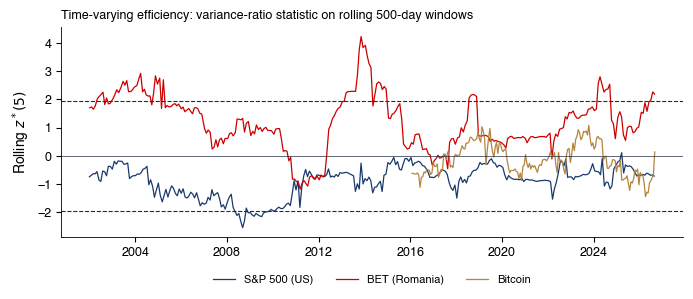

share of windows with |z*| > 1.96 {'sp500': 0.06418918918918919, 'bet': 0.22448979591836735, 'btc': 0.0}


In [14]:
WINDOW, STEP = 500, 21
ROLL = [('sp500', MainBlue), ('bet', IDAred), ('btc', Amber)]


def fig_rolling_vr():
    fig, ax = plt.subplots(figsize=(7.0, 3.1))
    out = {}
    for k, c in ROLL:
        z = rolling_stat(rets[k], lambda x: variance_ratio(x, 5)[2], WINDOW, STEP)
        out[k] = z
        ax.plot(z.index, z.values, color=c, lw=0.9, label=LABELS[k])
    for x in (-1.96, 1.96):
        ax.axhline(x, color=Gray, ls='--', lw=0.8)
    ax.axhline(0, color=Gray, lw=0.5)
    ax.set_ylabel(r'Rolling $z^*(5)$')
    ax.set_title(f'Time-varying efficiency: variance-ratio statistic on rolling {WINDOW}-day windows',
                 fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=3, y=-0.13)
    plt.tight_layout()
    save_fig('ch2_rolling_vr')
    share = {k: float((z.abs() > 1.96).mean()) for k, z in out.items()}
    pd.DataFrame(out).to_csv(os.path.join(TABLE_DIR, 'ch2_rolling_vr.csv'))
    return share


print('share of windows with |z*| > 1.96', fig_rolling_vr())

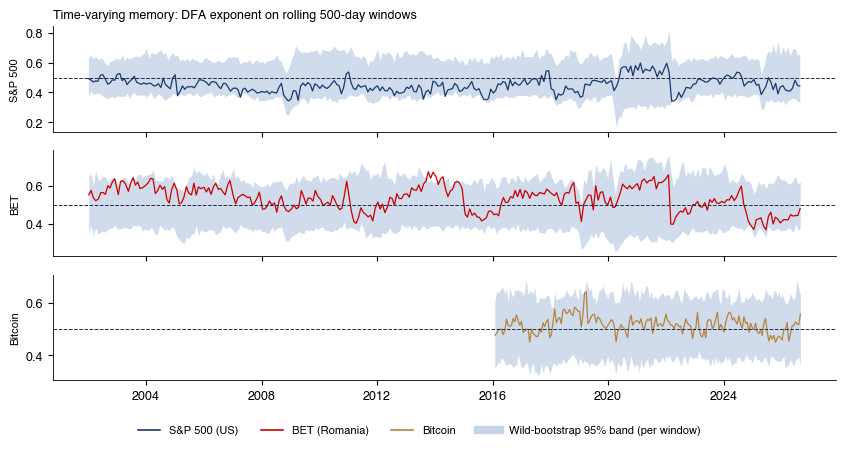

((np.float64(0.3778242224128016), np.float64(0.6143493884737028)), {'sp500': 0.02027027027027027, 'bet': 0.027210884353741496, 'btc': 0.0}, {'sp500': 0.06418918918918919, 'bet': 0.1292517006802721, 'btc': 0.010810810810810811}, {'sp500': [0.3587853560649089, 0.6438014682118395], 'bet': [0.3606758576568218, 0.6444955224911435], 'btc': [0.37348367273991606, 0.6302272779125928]})


In [15]:
def fig_rolling_hurst(n_sim=199):
    """Rolling DFA; wild-bootstrap null band computed separately for EACH window
    (keeps the window's volatility, allowed under RW3). For comparison: the i.i.d. Student-t4 band."""
    rng = np.random.default_rng(SEED)
    null = [dfa_hurst(rng.standard_t(4, WINDOW))[0] for _ in range(300)]
    lo_t, hi_t = np.percentile(null, [2.5, 97.5])
    dfa = lambda x: dfa_hurst(x)[0]
    fig, axes = plt.subplots(3, 1, figsize=(8.6, 4.2), sharex=True)
    out, share, share_t = {}, {}, {}
    for ax, (k, c) in zip(axes, ROLL):
        x = rets[k].values
        rows = []
        for end in range(WINDOW, len(x) + 1, STEP):
            w = x[end - WINDOW:end]
            lo, hi = wild_band(w, dfa, n_sim, SEED + end)
            rows.append((rets[k].index[end - 1], dfa(w), lo, hi))
        d = pd.DataFrame(rows, columns=['date', 'dfa', 'lo', 'hi']).set_index('date')
        out[k] = d
        share[k] = float(((d['dfa'] < d['lo']) | (d['dfa'] > d['hi'])).mean())
        share_t[k] = float(((d['dfa'] < lo_t) | (d['dfa'] > hi_t)).mean())
        ax.fill_between(d.index, d['lo'], d['hi'], color=LightGray, alpha=0.8, lw=0)
        ax.plot(d.index, d['dfa'], color=c, lw=0.9)
        ax.axhline(0.5, color=Gray, ls='--', lw=0.7)
        ax.set_ylabel(LABELS[k].split(' (')[0], fontsize=8)
    axes[0].set_title(f'Time-varying memory: DFA exponent on rolling {WINDOW}-day windows', fontsize=9, loc='left')
    handles = [plt.Line2D([], [], color=c, lw=1.2, label=LABELS[k]) for k, c in ROLL]
    handles.append(plt.Line2D([], [], color=LightGray, lw=6, label='Wild-bootstrap 95% band (per window)'))
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=4, frameon=False)
    plt.tight_layout()
    save_fig('ch2_rolling_hurst')
    pd.concat(out, axis=1).to_csv(os.path.join(TABLE_DIR, 'ch2_rolling_hurst.csv'))
    band_mean = {k: [float(d['lo'].mean()), float(d['hi'].mean())] for k, d in out.items()}
    return (lo_t, hi_t), share, share_t, band_mean


print(fig_rolling_hurst())

## 8. Crypto efficiency year by year

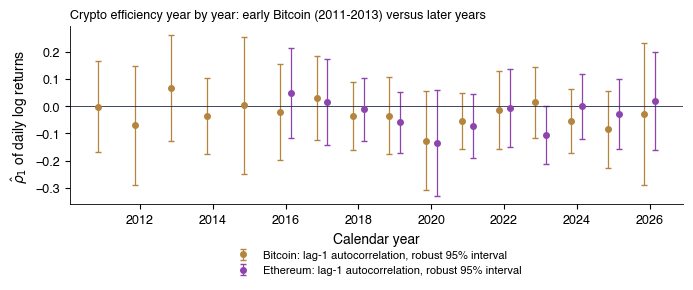

,asset,year,n,rho1,rho1_se,VR5,zstar5
0,Bitcoin,2011,364,-0.002,0.086,1.288,1.712
1,Bitcoin,2012,366,-0.071,0.112,1.084,0.371
2,Bitcoin,2013,365,0.069,0.100,1.144,0.645
3,Bitcoin,2014,365,-0.036,0.071,0.827,-1.213
4,Bitcoin,2015,365,0.004,0.129,0.894,-0.457
5,Bitcoin,2016,366,-0.021,0.091,0.966,-0.191
6,Bitcoin,2017,365,0.031,0.079,0.984,-0.103
7,Bitcoin,2018,365,-0.035,0.064,1.048,0.354
8,Bitcoin,2019,365,-0.034,0.073,0.980,-0.126
9,Bitcoin,2020,366,-0.126,0.094,0.917,-0.461


In [16]:
def crypto_yearly():
    rows = []
    for k, start in [('btc', '2011-01-01'), ('eth', '2016-01-01')]:
        r = log_returns(k, start=start)
        for y, ry in r.groupby(r.index.year):
            if len(ry) < 200:
                continue
            e = ry - ry.mean()
            tau1 = (e.values[1:] ** 2 * e.values[:-1] ** 2).sum() / (e ** 2).sum() ** 2
            vr, _, zs = variance_ratio(ry, 5)
            rows.append(dict(asset=LABELS[k], year=y, n=len(ry), rho1=ry.autocorr(1), rho1_se=np.sqrt(tau1),
                             VR5=vr, zstar5=zs))
    d = pd.DataFrame(rows)
    d.to_csv(os.path.join(TABLE_DIR, 'ch2_crypto_yearly.csv'), index=False, float_format='%.6g')
    return d


def fig_crypto_yearly():
    d = crypto_yearly()
    fig, ax = plt.subplots(figsize=(7.0, 3.1))
    for (a, c, off) in [('Bitcoin', Amber, -0.15), ('Ethereum', Purple, 0.15)]:
        s = d[d['asset'] == a]
        ax.errorbar(s['year'] + off, s['rho1'], yerr=1.96 * s['rho1_se'], fmt='o', ms=4, color=c, capsize=2,
                    lw=0.9, label=f'{a}: lag-1 autocorrelation, robust 95% interval')
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_xlabel('Calendar year')
    ax.set_ylabel(r'$\hat\rho_1$ of daily log returns')
    ax.set_title('Crypto efficiency year by year: early Bitcoin (2011-2013) versus later years', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=1, y=-0.2)
    plt.tight_layout()
    save_fig('ch2_crypto_yearly')
    return d


fig_crypto_yearly().round(3)

## 9. Semi-strong efficiency: event studies

- The bank-tax event study (December 2018) is computed in Section 13 below; the single-bank version is Seminar 0, B7, and the two-bank version Seminar 2, B9.

## 10. Calendar anomalies with HAC errors

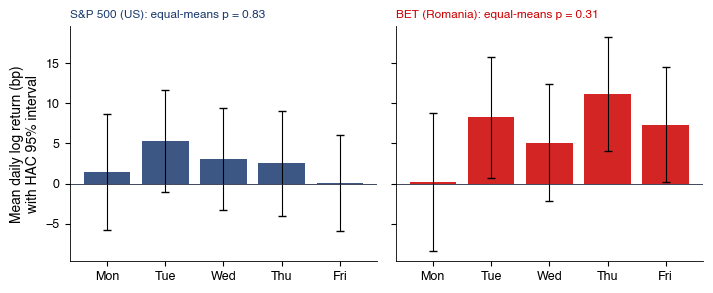

{'sp500': 0.8263343912438967, 'bet': 0.30516320622792}


market,S&P 500 (US),BET (Romania),Euro Stoxx 50,WIG20 (Poland),BUX (Hungary)
Mon_bp,1.394,0.200,-3.947,7.849,7.448
Tue_bp,5.318,8.241,4.220,3.355,3.979
Wed_bp,3.011,5.108,1.428,-2.446,3.771
Thu_bp,2.530,11.170,1.678,1.041,2.531
Fri_bp,0.015,7.339,-1.449,-3.943,3.780
Mon_t,0.378,0.046,-0.955,1.856,1.837
Tue_t,1.646,2.137,1.205,0.836,1.048
Wed_t,0.930,1.373,0.402,-0.625,0.906
Thu_t,0.757,3.087,0.445,0.238,0.642
Fri_t,0.005,1.998,-0.393,-1.035,1.021


In [17]:
DAYS = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']


def dow_regression(r):
    """Daily return on weekday dummies (no constant), Newey-West errors."""
    r = complete_months(r)
    X = pd.get_dummies(r.index.dayofweek).astype(float)
    X.columns = DAYS
    X.index = r.index
    res = sm.OLS(r * 1e4, X).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    # Wald test of equal means, with the same HAC errors
    R = np.zeros((4, 5))
    for i in range(4):
        R[i, 0], R[i, i + 1] = 1, -1
    w = res.wald_test(R, scalar=True)
    return res, float(w.pvalue)


def january_regression(r):
    m = np.exp(complete_months(r).groupby(pd.Grouper(freq='ME')).sum()) - 1
    X = sm.add_constant(pd.Series((m.index.month == 1).astype(float), index=m.index, name='January'))
    res = sm.OLS(m * 100, X).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
    return res


def turn_of_month(r):
    """Dummy for the last trading day of the month and the first three days of the next month (Ariel, 1987)."""
    d = pd.DataFrame({'r': complete_months(r) * 1e4})
    ym = d.index.to_period('M')
    rank = d.groupby(ym).cumcount()
    rank_end = d.groupby(ym).cumcount(ascending=False)
    d['tom'] = ((rank < 3) | (rank_end == 0)).astype(float)
    res = sm.OLS(d['r'], sm.add_constant(d['tom'])).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    return res


def calendar_table():
    rows = []
    for k in ['sp500', 'bet', 'stoxx', 'wig20', 'bux']:
        r = rets[k]
        res, p_eq = dow_regression(r)
        jan = january_regression(r)
        tom = turn_of_month(r)
        rows.append(dict(market=LABELS[k], **{f'{d}_bp': res.params[d] for d in DAYS},
                         **{f'{d}_t': res.tvalues[d] for d in DAYS}, dow_equal_p=p_eq,
                         jan_extra_pct=jan.params['January'], jan_t=jan.tvalues['January'],
                         tom_extra_bp=tom.params['tom'], tom_t=tom.tvalues['tom'], tom_p=tom.pvalues['tom']))
    t = pd.DataFrame(rows).set_index('market')
    t.to_csv(os.path.join(TABLE_DIR, 'ch2_calendar_table.csv'), float_format='%.6g')
    return t


def fig_calendar():
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0), sharey=True)
    out = {}
    for ax, (k, c) in zip(axes, [('sp500', MainBlue), ('bet', IDAred)]):
        res, p_eq = dow_regression(rets[k])
        ci = res.conf_int()
        out[k] = p_eq
        ax.bar(DAYS, res.params.values, color=c, alpha=0.85)
        ax.errorbar(DAYS, res.params.values, yerr=[res.params - ci[0], ci[1] - res.params], fmt='none',
                    ecolor='k', capsize=3, lw=0.8)
        ax.axhline(0, color=Gray, lw=0.6)
        ax.set_title(f'{LABELS[k]}: equal-means p = {p_eq:.2f}', fontsize=8.5, loc='left', color=c)
    axes[0].set_ylabel('Mean daily log return (bp)\nwith HAC 95% interval')
    plt.tight_layout()
    save_fig('ch2_calendar')
    return out


print(fig_calendar())
calendar_table().round(3).T

## 11. Multiple testing: anomalies produced by chance

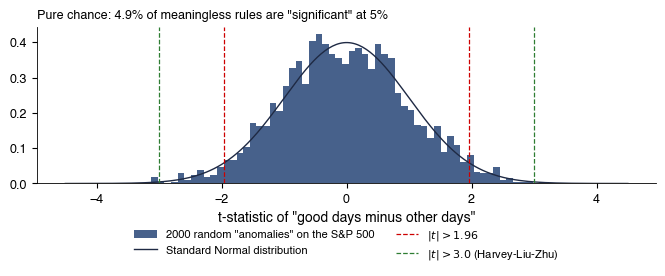

{'share_196': 0.049,
 'share_3': 0.0025,
 'max_abs_t': 3.187754688626965,
 'n': 2000}

In [18]:
def fig_multiple_testing(n_rules=2000, seed=SEED):
    """Random calendar rules on the S&P 500: each picks 20% of the days at random as 'good days'."""
    rng = np.random.default_rng(seed)
    r = rets['sp500'] * 1e4
    x = r.values
    ts = []
    for _ in range(n_rules):
        mask = rng.random(len(x)) < 0.2
        d = x[mask].mean() - x[~mask].mean()
        se = np.sqrt(x[mask].var(ddof=1) / mask.sum() + x[~mask].var(ddof=1) / (~mask).sum())
        ts.append(d / se)
    ts = np.array(ts)
    fig, ax = plt.subplots(figsize=(6.8, 3.0))
    ax.hist(ts, bins=60, color=MainBlue, alpha=0.8, density=True, label=f'{n_rules} random "anomalies" on the S&P 500')
    xx = np.linspace(-4.5, 4.5, 300)
    ax.plot(xx, np.exp(-xx ** 2 / 2) / np.sqrt(2 * np.pi), color=Gray, lw=1, label='Standard Normal distribution')
    for v, lab, c in [(1.96, r'$|t| > 1.96$', IDAred), (3.0, r'$|t| > 3.0$ (Harvey-Liu-Zhu)', Forest)]:
        ax.axvline(v, color=c, ls='--', lw=0.9, label=lab)
        ax.axvline(-v, color=c, ls='--', lw=0.9)
    ax.set_xlabel('t-statistic of "good days minus other days"')
    ax.set_title(f'Pure chance: {np.mean(np.abs(ts) > 1.96):.1%} of meaningless rules are "significant" at 5%',
                 fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.22)
    plt.tight_layout()
    save_fig('ch2_multiple_testing')
    return dict(share_196=float(np.mean(np.abs(ts) > 1.96)), share_3=float(np.mean(np.abs(ts) > 3.0)),
                max_abs_t=float(np.abs(ts).max()), n=n_rules)


fig_multiple_testing()

## 12. Index-level time-series momentum

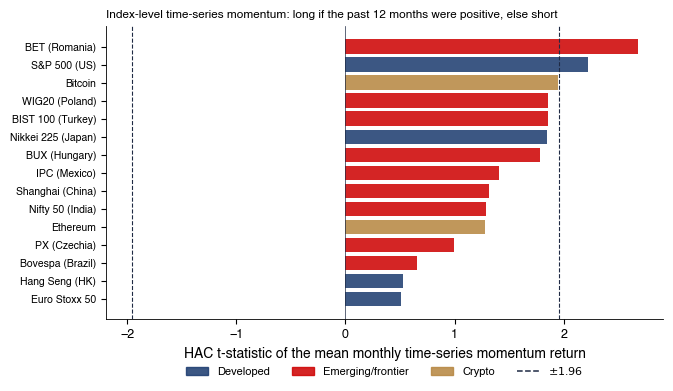

,market,group,months,tsmom_mean_pct,t_hac,sharpe_tsmom,sharpe_bh,rho1_monthly
stoxx,Euro Stoxx 50,Developed,307,0.159,0.507,0.107,0.155,0.045
hsi,Hang Seng (HK),Developed,307,0.179,0.525,0.101,0.191,0.044
bvsp,Bovespa (Brazil),Emerging/frontier,307,0.275,0.654,0.141,0.508,0.107
px,PX (Czechia),Emerging/frontier,307,0.375,0.995,0.238,0.454,0.104
eth,Ethereum,Crypto,115,6.498,1.281,0.571,0.902,0.158
nsei,Nifty 50 (India),Emerging/frontier,307,0.497,1.292,0.277,0.637,0.021
ssec,Shanghai (China),Emerging/frontier,307,0.594,1.318,0.297,0.228,0.084
mxx,IPC (Mexico),Emerging/frontier,307,0.444,1.407,0.316,0.627,0.035
bux,BUX (Hungary),Emerging/frontier,307,0.725,1.786,0.404,0.644,0.103
nikkei,Nikkei 225 (Japan),Developed,307,0.614,1.850,0.387,0.419,0.088


In [19]:
def tsmom_table():
    rows = []
    for k in [m for m in ORDER if m != 'eurron']:
        p = complete_months(load_close(k))
        pm = p.resample('ME').last()
        m = np.log(pm).diff().dropna()                          # monthly log returns: for the signal only
        R = pm.pct_change().dropna()                            # simple returns: the position's payoff
        sig = np.sign(m.rolling(12).sum().shift(1))            # sign of the past 12-month return
        s = (sig * R).dropna()                                  # long +1 / short -1, before funding and costs
        res = sm.OLS(s * 100, np.ones(len(s))).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
        bh = R.loc[s.index]
        rows.append(dict(market=LABELS[k], group=GROUPS[k], months=len(s),
                         tsmom_mean_pct=res.params.iloc[0], t_hac=res.tvalues.iloc[0],
                         sharpe_tsmom=np.sqrt(12) * s.mean() / s.std(), sharpe_bh=np.sqrt(12) * bh.mean() / bh.std(),
                         rho1_monthly=m.autocorr(1)))
    t = pd.DataFrame(rows, index=[m for m in ORDER if m != 'eurron'])
    t.to_csv(os.path.join(TABLE_DIR, 'ch2_tsmom_table.csv'), float_format='%.6g')
    return t


def fig_tsmom():
    t = tsmom_table().sort_values('t_hac')
    fig, ax = plt.subplots(figsize=(6.8, 4.0))
    ax.barh(np.arange(len(t)), t['t_hac'], color=[GROUP_COL[g] for g in t['group']], alpha=0.85)
    for x in (-1.96, 1.96):
        ax.axvline(x, color=Gray, ls='--', lw=0.8)
    ax.axvline(0, color=Gray, lw=0.5)
    ax.set_yticks(np.arange(len(t)), t['market'], fontsize=7.5)
    ax.set_xlabel('HAC t-statistic of the mean monthly time-series momentum return')
    handles = [plt.Rectangle((0, 0), 1, 1, color=GROUP_COL[g], alpha=0.85, label=g)
               for g in ['Developed', 'Emerging/frontier', 'Crypto']]
    handles.append(plt.Line2D([], [], color=Gray, ls='--', label=r'$\pm 1.96$'))
    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False)
    ax.set_title('Index-level time-series momentum: long if the past 12 months were positive, else short',
                 fontsize=8.5, loc='left')
    plt.tight_layout()
    save_fig('ch2_tsmom')
    return t


fig_tsmom().round(3)

## 13. Predictive regressions, long memory with inference, event studies and dependent tests

- Monthly S&P Composite prices and dividends (Robert J. Shiller), extended with S&P 500 closes and SPY dividends; 3-month T-bill rate (FRED `TB3MS`).
- Stambaugh bias, out-of-sample $R^2$ with Clark–West, local Whittle $\hat d$, the Escanciano–Lobato test, the bank-tax event study, StepM and the AMH regression.

In [20]:
SHILLER_URLS = ['http://www.econ.yale.edu/~shiller/data/ie_data.xls']
FRED = 'https://fred.stlouisfed.org/graph/fredgraph.csv?id='
CAL_MARKETS = ['sp500', 'bet', 'stoxx', 'wig20', 'bux']
_R = np.column_stack([np.ones(4), -np.eye(4)])


def _get(url, timeout=120, agent='Mozilla/5.0'):
    return urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': agent}),
                                  timeout=timeout).read()


def shiller():
    """Monthly S&P Composite (Robert J. Shiller's public data): P = monthly average price,
    D = trailing 12-month dividends (nominal)."""
    if 'shiller' in _CACHE:
        return _CACHE['shiller']
    urls = []
    try:
        html = _get('https://shillerdata.com/', 60).decode('utf-8', 'ignore')
        urls = ['https:' + u if u.startswith('//') else u for u in re.findall(r'href="([^"]*ie_data\.xls[^"]*)"', html)]
    except Exception:
        pass
    raw = None
    for url in urls + SHILLER_URLS:
        try:
            raw = _get(url)
            break
        except Exception:
            continue
    d = pd.read_excel(io.BytesIO(raw), sheet_name='Data', header=None, skiprows=8).iloc[:, [0, 1, 2]]
    d.columns = ['date', 'P', 'D']
    d = d[pd.to_numeric(d['date'], errors='coerce').notna()].copy()
    yr = d['date'].astype(float)
    year = np.floor(yr + 1e-9).astype(int)
    month = np.round((yr - year) * 100).astype(int)
    d.index = pd.to_datetime(dict(year=year, month=month, day=1)) + pd.offsets.MonthEnd(0)
    d = d[['P', 'D']].apply(pd.to_numeric, errors='coerce').dropna()
    _CACHE['shiller'] = d
    return d


def fred(series):
    """FRED series (no API key), as a pd.Series indexed at month ends."""
    d = pd.read_csv(io.BytesIO(_get(FRED + series, agent='Python-urllib')), index_col=0, parse_dates=True)
    s = pd.to_numeric(d.iloc[:, 0], errors='coerce').dropna()
    s.index = s.index + pd.offsets.MonthEnd(0)
    return s.rename(series)


def sp500_monthly(end='2026-08-31'):
    """Monthly S&P 500, P (monthly average) and D (trailing 12-month dividends), extended to `end`.
    Splicing: P = monthly average of the daily S&P 500 closes; D = trailing 12-month dividends of the SPY fund
    (from the adjusted and unadjusted closes), scaled by the mean ratio D_Shiller / D_SPY over the last 12 common months."""
    sh = shiller()
    spx = read_market('GSPC.INDX')['close']
    P_ext = spx.resample('ME').mean()
    spy = read_market('SPY.US')
    tr = spy['adjusted_close'] / spy['adjusted_close'].shift(1)
    div = (tr * spy['close'].shift(1) - spy['close']).clip(lower=0)
    div[div < 1e-3 * spy['close']] = 0.0                       # ex-dividend days only
    D_spy = div.resample('ME').sum().rolling(12).sum()
    common = sh.index.intersection(D_spy.dropna().index)[-12:]
    kP = float((sh.loc[common, 'P'] / P_ext.loc[common]).mean())
    kD = float((sh.loc[common, 'D'] / D_spy.loc[common]).mean())
    last = sh.index[-1]
    ext = pd.DataFrame({'P': kP * P_ext, 'D': kD * D_spy}).loc[last + pd.offsets.MonthEnd(1):end]
    out = pd.concat([sh, ext]).loc[:end]
    out.attrs.update(shiller_last=str(last.date()), kP=kP, kD=kD)
    return out


def monthly_data(start='1934-01-31', end='2026-08-31'):
    """S&P 500 monthly excess log return (with dividends) and log D/P at the end of the previous month."""
    d = sp500_monthly(end)
    rf = fred('TB3MS') / 100                                   # annualised 3-month T-bill rate
    r = np.log((d['P'] + d['D'] / 12) / d['P'].shift(1))
    rf_m = np.log(1 + rf / 12).reindex(d.index).shift(1)       # known at the start of the month
    out = pd.DataFrame({'ex': r - rf_m, 'dp': np.log(d['D'] / d['P'])})
    out['dp_lag'] = out['dp'].shift(1)
    return out.loc[start:end].dropna(), d.attrs


def predictive_regression(df, nw_lags=12):
    """OLS with Newey-West errors, AR(1) regression of the predictor, innovation correlation and the Stambaugh correction."""
    y, x = df['ex'].values, df['dp_lag'].values
    X = sm.add_constant(x)
    ols = sm.OLS(y, X).fit()
    hac = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': nw_lags})
    ar = sm.OLS(df['dp'].values, X).fit()                      # dp_t on dp_{t-1}
    u, v = ols.resid, ar.resid
    T = len(y)
    rho = ar.params[1]
    s_uv, s_vv = np.cov(u, v)[0, 1], np.var(v, ddof=1)
    bias_rho = -(1 + 3 * rho) / T                               # Kendall (1954)
    bias_beta = s_uv / s_vv * bias_rho                          # Stambaugh (1999)
    return dict(T=T, start=str(df.index[0].date()), end=str(df.index[-1].date()),
                beta=ols.params[1], se_ols=ols.bse[1], t_ols=ols.tvalues[1], se_nw=hac.bse[1], t_nw=hac.tvalues[1],
                r2=ols.rsquared, rho=rho, corr_uv=np.corrcoef(u, v)[0, 1], ratio_uv=s_uv / s_vv,
                bias_rho=bias_rho, bias_beta=bias_beta, beta_adj=ols.params[1] - bias_beta,
                t_adj=(ols.params[1] - bias_beta) / hac.bse[1])


def simulate_stambaugh(rho, corr_uv, T, n_sim=2000, seed=SEED):
    """Bias of beta and size of the 5% t-test when beta = 0 (persistent predictor, correlated innovations)."""
    rng = np.random.default_rng(seed)
    betas, rej = [], 0
    for _ in range(n_sim):
        e = rng.multivariate_normal([0, 0], [[1, corr_uv], [corr_uv, 1]], T + 1)
        x = np.zeros(T + 1)
        for t in range(1, T + 1):
            x[t] = rho * x[t - 1] + e[t, 1]
        y = e[1:, 0]                                             # beta = 0
        f = sm.OLS(y, sm.add_constant(x[:-1])).fit()
        betas.append(f.params[1] / 1.0)
        rej += abs(f.tvalues[1]) > 1.96
    return dict(mean_beta=float(np.mean(betas)), size=rej / n_sim)


def oos_r2(df, oos_start='1970-01-31', nw_lags=12):
    """Recursive (expanding-window) forecasts: predictive regression vs historical mean.
    R2_OS (Welch-Goyal), Clark-West, and the version with Campbell-Thompson restrictions."""
    rows = []
    idx = df.index
    first = idx.get_loc(idx[idx >= oos_start][0])
    for i in range(first, len(df)):
        est = df.iloc[:i]
        b = np.polyfit(est['dp_lag'], est['ex'], 1)
        f_pred = b[1] + b[0] * df['dp_lag'].iloc[i]
        f_ct = max(b[1] + max(b[0], 0.0) * df['dp_lag'].iloc[i], 0.0) if b[0] > 0 else max(est['ex'].mean(), 0.0)
        rows.append((idx[i], df['ex'].iloc[i], est['ex'].mean(), f_pred, f_ct))
    o = pd.DataFrame(rows, columns=['date', 'y', 'mean', 'pred', 'ct']).set_index('date')
    e0, e1, e2 = o['y'] - o['mean'], o['y'] - o['pred'], o['y'] - o['ct']
    r2 = 1 - (e1 ** 2).sum() / (e0 ** 2).sum()
    r2_ct = 1 - (e2 ** 2).sum() / (e0 ** 2).sum()
    f = e0 ** 2 - (e1 ** 2 - (o['mean'] - o['pred']) ** 2)            # Clark-West
    cw = sm.OLS(f.values, np.ones(len(f))).fit(cov_type='HAC', cov_kwds={'maxlags': nw_lags})
    dm = sm.OLS((e0 ** 2 - e1 ** 2).values, np.ones(len(f))).fit(cov_type='HAC', cov_kwds={'maxlags': nw_lags})
    o['cum_dsse'] = (e0 ** 2 - e1 ** 2).cumsum()
    o['cum_dsse_ct'] = (e0 ** 2 - e2 ** 2).cumsum()
    sr_m = df['ex'].mean() / df['ex'].std()                       # unconditional monthly Sharpe ratio
    binds = float(((o['ct'] - o['pred']).abs() > 1e-12).mean())       # how often the restrictions bind
    ct_gain = lambda r2_: r2_ / (1 - r2_) * (1 + sr_m ** 2) / sr_m ** 2
    return o, dict(n=len(o), start=str(o.index[0].date()), r2=r2, r2_ct=r2_ct, cw_t=cw.tvalues[0],
                   cw_p=1 - stats.norm.cdf(cw.tvalues[0]), dm_t=dm.tvalues[0], sr_m=sr_m,
                   gain_05=ct_gain(0.005), ct_binds=binds, gain_ct=ct_gain(r2_ct) if r2_ct > 0 else float('nan'))


def fig_oos(o):
    fig, ax = plt.subplots(figsize=(7.0, 3.0))
    ax.plot(o.index, o['cum_dsse'], color=IDAred, lw=1.0, label='Predictive regression on log D/P vs historical mean')
    ax.axhline(0, color=Gray, lw=0.7, ls='--')
    ax.set_ylabel('Cumulative reduction in squared\nforecast errors vs historical mean')
    ax.set_title('Out-of-sample: does the dividend-price ratio beat the historical mean? (S&P 500, monthly)',
                 fontsize=9, loc='left')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.13), ncol=1, frameon=False)
    plt.tight_layout()
    save_fig('ch2_oos_dp')


def local_whittle(x, m):
    """d estimated by minimising the local Whittle function (Robinson, 1995); asymptotic SE 1/(2 sqrt(m))."""
    x = np.asarray(x, dtype=float)
    T = len(x)
    w = np.fft.fft(x - x.mean())
    lam = 2 * np.pi * np.arange(1, m + 1) / T
    I = np.abs(w[1:m + 1]) ** 2 / (2 * np.pi * T)
    from scipy.optimize import minimize_scalar
    R = lambda d: np.log(np.mean(lam ** (2 * d) * I)) - 2 * d * np.mean(np.log(lam))
    d = minimize_scalar(R, bounds=(-0.49, 0.99), method='bounded').x
    return d, 1 / (2 * np.sqrt(m))


def el_autoportmanteau(x, d_max=10, q=2.4):
    """AQ = T sum_{j<=p~} rho~_j^2 with rho~_j^2 = gamma_j^2 / tau_j (robust); p~ chosen from the data; AQ ~ chi2(1)."""
    y = np.asarray(x, dtype=float)
    T = len(y)
    e = y - y.mean()
    g0 = (e ** 2).mean()
    rt = []
    rho_raw = []
    for j in range(1, d_max + 1):
        gj = (e[j:] * e[:-j]).sum() / (T - j)
        tj = (e[j:] ** 2 * e[:-j] ** 2).sum() / (T - j)
        rt.append(gj ** 2 / tj)
        rho_raw.append(gj / g0)
    rt = np.array(rt)
    Q = T * np.cumsum(rt)
    p = np.arange(1, d_max + 1)
    pen = p * np.log(T) if np.sqrt(T * np.max(rt)) <= np.sqrt(q * np.log(T)) else 2 * p   # switch based on the robust correlations
    L = Q - pen
    pt = int(p[np.argmax(L)])
    AQ = Q[pt - 1]
    return AQ, pt, 1 - stats.chi2.cdf(AQ, 1)


def event_study_bank_tax(event='2018-12-19', est=(-250, -11), win=(0, 5)):
    """Market model on [-250, -11]; abnormal returns with the prediction-error variance; portfolio test vs independence."""
    px = pd.concat({'TLV': read_market('TLV.RO')['adjusted_close'], 'BRD': read_market('BRD.RO')['adjusted_close'],
                    'BET': read_market('BET')['close']}, axis=1).dropna()        # align prices on common trading days
    px = px[px.index.dayofweek < 5]
    r = np.log(px).diff().dropna()
    t0 = r.index.get_loc(pd.Timestamp(event))
    E = r.iloc[t0 + est[0]:t0 + est[1] + 1]
    W = r.iloc[t0 + win[0]:t0 + win[1] + 1]
    rm, mu_m, var_m, T0 = W['BET'], E['BET'].mean(), E['BET'].var(ddof=1), len(E)
    out, resid = {}, {}
    for k in ['TLV', 'BRD', 'PORT']:
        yE = E[['TLV', 'BRD']].mean(axis=1) if k == 'PORT' else E[k]
        yW = W[['TLV', 'BRD']].mean(axis=1) if k == 'PORT' else W[k]
        f = sm.OLS(yE, sm.add_constant(E['BET'])).fit()
        s2 = f.mse_resid
        resid[k] = f.resid
        ar = yW - f.params['const'] - f.params['BET'] * rm
        pe = s2 * (1 + 1 / T0 + (rm - mu_m) ** 2 / ((T0 - 1) * var_m))          # prediction-error variance
        car = ar.sum()
        # CAR: sum of prediction variances + covariance induced by parameter estimation (MacKinlay, 1997)
        Xs = np.column_stack([np.ones(len(rm)), rm.values])
        XE = np.column_stack([np.ones(T0), E['BET'].values])
        V = s2 * (np.eye(len(rm)) + Xs @ np.linalg.inv(XE.T @ XE) @ Xs.T)
        out[k] = dict(beta=f.params['BET'], sigma=np.sqrt(s2), ar0=ar.iloc[0], t0_naive=ar.iloc[0] / np.sqrt(s2),
                      t0=ar.iloc[0] / np.sqrt(pe.iloc[0]), infl0=pe.iloc[0] / s2, car=car,
                      t_car=car / np.sqrt(V.sum()), t_car_naive=car / np.sqrt(s2 * len(rm)),
                      var_car=V.sum(), car_post=ar.iloc[1:].sum(), t_car_post=ar.iloc[1:].sum() / np.sqrt(V[1:, 1:].sum()))
    rbar = np.corrcoef(resid['TLV'], resid['BRD'])[0, 1]
    # joint test assuming independence: mean AR0 / (sqrt(s1^2 + s2^2)/2)
    # under independence: the same prediction-error variances as for the portfolio, no covariance between firms
    s_ind = np.sqrt(out['TLV']['sigma'] ** 2 * out['TLV']['infl0'] + out['BRD']['sigma'] ** 2 * out['BRD']['infl0']) / 2
    ar0_mean = (out['TLV']['ar0'] + out['BRD']['ar0']) / 2
    car_mean = (out['TLV']['car'] + out['BRD']['car']) / 2
    s_car_ind = np.sqrt(out['TLV']['var_car'] + out['BRD']['var_car']) / 2
    return dict(event=event, rm0=float(rm.iloc[0]), T0=T0, rbar=rbar, firms=out,
                ar0_mean=ar0_mean, t_indep=ar0_mean / s_ind, t_port=out['PORT']['t0'],
                car_mean=car_mean, tcar_indep=car_mean / s_car_ind, tcar_port=out['PORT']['t_car'],
                kp_factor=np.sqrt((1 - rbar) / (1 + rbar)),
                varmean10=1 + 9 * rbar,                       # Var(mean of 10 ARs) / Var under independence
                kp_inflation10=(1 + 9 * rbar) / (1 - rbar))  # overstatement of the variance of the cross-sectional statistic


def _nw_se(X, u, L=5):
    """Newey-West covariance matrix (Bartlett kernel, L lags) for OLS."""
    T = len(u)
    Xu = X * u[:, None]
    S = Xu.T @ Xu / T
    for j in range(1, L + 1):
        G = Xu[j:].T @ Xu[:-j] / T
        S += (1 - j / (L + 1)) * (G + G.T)
    XX = np.linalg.inv(X.T @ X / T)
    return XX @ S @ XX / T


def _cal_est(r, dow, month):
    """Estimates and HAC covariances of the 3 effects for one market.
    dow: weekday of each observation; month: integer month label, (block or year) * 100 + month."""
    D = np.column_stack([(dow == d).astype(float) for d in range(5)])
    grp = pd.Series(np.arange(len(r))).groupby(month)
    rank = grp.cumcount().values
    rank_end = grp.cumcount(ascending=False).values
    tom = ((rank < 3) | (rank_end == 0)).astype(float)
    bd = np.linalg.lstsq(D, r, rcond=None)[0]
    Vd = _nw_se(D, r - D @ bd, 5)
    X = np.column_stack([np.ones(len(r)), tom])
    bt = np.linalg.lstsq(X, r, rcond=None)[0]
    Vt = _nw_se(X, r - X @ bt, 5)
    ms = np.expm1(pd.Series(r).groupby(month).sum())          # simple monthly returns, as in january_regression
    jan = (np.asarray(ms.index) % 100 == 1).astype(float)
    Xm = np.column_stack([np.ones(len(ms)), jan])
    bj = np.linalg.lstsq(Xm, ms.values, rcond=None)[0]
    Vj = _nw_se(Xm, ms.values - Xm @ bj, 3)
    return dict(dow=(bd, Vd), tom=(bt[1], Vt[1, 1]), jan=(bj[1], Vj[1, 1]))


def _cal_p(est, center=None):
    """p-values: Wald (4 df) for the day of the week, two-sided z for January and TOM.
    center: the estimates on the original data (bootstrap statistic centred, as in Romano-Wolf)."""
    out = {}
    bd, Vd = est['dow']
    d = _R @ (bd - (center['dow'][0] if center else 0))
    out['dow'] = 1 - stats.chi2.cdf(float(d @ np.linalg.solve(_R @ Vd @ _R.T, d)), 4)
    for e in ['jan', 'tom']:
        b, v = est[e]
        z = (b - (center[e][0] if center else 0)) / np.sqrt(v)
        out[e] = 2 * (1 - stats.norm.cdf(abs(z)))
    return out


def stepm_calendar(n_boot=999, block=3, alpha=0.05, seed=SEED):
    """Romano-Wolf StepM with the min-p statistic: the SAME blocks of calendar months are resampled for
    all markets (keeps the dependence across markets and the calendar structure within the month);
    the bootstrap statistics are centred at the original estimates."""
    rets = {k: complete_months(log_returns(k)) for k in CAL_MARKETS}
    months = pd.period_range('2000-01', max(r.index[-1] for r in rets.values()).to_period('M'), freq='M')
    orig, p0, pos = {}, {}, {}
    for k, r in rets.items():
        mlab = r.index.to_period('M')
        orig[k] = _cal_est(r.values, r.index.dayofweek.values, r.index.year.values * 100 + r.index.month.values)
        for e, pv in _cal_p(orig[k]).items():
            p0[(k, e)] = pv
        pos[k] = {m: np.where(mlab == m)[0] for m in months}
    keys = [(k, e) for k in CAL_MARKETS for e in ['dow', 'jan', 'tom']]
    mnum = np.array([m.month for m in months])
    rng = np.random.default_rng(seed)
    nb = int(np.ceil(len(months) / block))
    boot_p = np.zeros((n_boot, len(keys)))
    for b in range(n_boot):
        starts = rng.integers(0, len(months) - block + 1, nb)
        msel = np.concatenate([np.arange(s0, s0 + block) for s0 in starts])[:len(months)]
        for k, r in rets.items():
            parts = [pos[k][months[m]] for m in msel]
            idx = np.concatenate(parts)
            lab = np.concatenate([np.full(len(pp), j) for j, pp in enumerate(parts)])
            newlab = lab * 100 + mnum[msel][lab]          # label = block position * 100 + original month
            est = _cal_est(r.values[idx], r.index.dayofweek.values[idx], newlab)
            for e, pv in _cal_p(est, orig[k]).items():
                boot_p[b, keys.index((k, e))] = pv
    p = np.array([p0[k] for k in keys])
    active = np.ones(len(keys), bool)
    rejected = np.zeros(len(keys), bool)
    steps = []
    while active.any():
        crit = np.quantile(boot_p[:, active].min(axis=1), alpha)
        new = active & (p <= crit)
        steps.append(float(crit))
        if not new.any():
            break
        rejected |= new
        active &= ~new
    holm = np.zeros(len(keys), bool)
    for i, ix in enumerate(np.argsort(p)):
        if p[ix] < alpha / (len(p) - i):
            holm[ix] = True
        else:
            break
    return pd.DataFrame({'market': [k for k, _ in keys], 'effect': [e for _, e in keys], 'p': p,
                         'holm_reject': holm, 'stepm_reject': rejected,
                         'boot_size5': (boot_p < 0.05).mean(axis=0)}), steps


def amh_regression(k, window=500, step=21):
    r = log_returns(k)
    z = rolling_stat(r, lambda x: variance_ratio(x, 5)[2], window, step)
    vol = rolling_stat(r, lambda x: np.std(x, ddof=1) * np.sqrt(252), window, step)
    starts = [r.index[r.index.get_loc(d) - window + 1] for d in z.index]
    crisis = [((s <= pd.Timestamp('2009-06-30')) & (e >= pd.Timestamp('2008-09-01'))) |
              ((s <= pd.Timestamp('2020-06-30')) & (e >= pd.Timestamp('2020-02-15'))) for s, e in zip(starts, z.index)]
    X = sm.add_constant(pd.DataFrame({'vol': 100 * vol.values, 'crisis': np.array(crisis, float)}))
    f = sm.OLS(z.values, X).fit(cov_type='HAC', cov_kwds={'maxlags': int(np.ceil(window / step))})
    return dict(n=len(z), b_vol=f.params['vol'], t_vol=f.tvalues['vol'], b_crisis=f.params['crisis'],
                t_crisis=f.tvalues['crisis'], r2=f.rsquared, lags=int(np.ceil(window / step)))


def show_predictive(pr):
    print(f"Predictive regression, {pr['start']} – {pr['end']}, T = {pr['T']} months")
    print(f"  OLS slope {100 * pr['beta']:.3f} (Newey–West SE {100 * pr['se_nw']:.3f}, t = {pr['t_nw']:.2f}; "
          f"OLS t = {pr['t_ols']:.2f}); R² = {100 * pr['r2']:.2f}%")
    print(f"  predictor AR(1) coefficient ρ = {pr['rho']:.4f}; corr(u, v) = {pr['corr_uv']:.2f}; "
          f"σ_uv/σ_v² = {pr['ratio_uv']:.3f}")
    print(f"  Stambaugh bias of the slope {100 * pr['bias_beta']:.3f}; "
          f"corrected slope {100 * pr['beta_adj']:.3f} (corrected slope / HAC SE = {pr['t_adj']:.2f})")


def show_oos(res):
    print(f"Out of sample from {res['start']} ({res['n']} months): R²_OS = {100 * res['r2']:.2f}%, "
          f"with Campbell–Thompson restrictions {100 * res['r2_ct']:.2f}% "
          f"(binding in {100 * res['ct_binds']:.1f}% of months)")
    print(f"  Clark–West t = {res['cw_t']:.2f} (one-sided p = {res['cw_p']:.2f}); "
          f"t-test of equal squared errors = {res['dm_t']:.2f}")
    print(f"  monthly Sharpe ratio {res['sr_m']:.3f}; "
          f"gain in expected return for R² = 0.5%: {100 * res['gain_05']:.0f}%")


def show_event(ev):
    print(f"Bank-tax event study, {ev['event']}: BET return on day 0 "
          f"{100 * ev['rm0']:.1f}%, estimation window {ev['T0']} days")
    for k in ('TLV', 'BRD', 'PORT'):
        f = ev['firms'][k]
        name = 'equal-weighted portfolio' if k == 'PORT' else k
        print(f"  {name}: AR0 = {100 * f['ar0']:.1f}% (t = {f['t0']:.2f}), CAR[0, +5] = {100 * f['car']:.1f}% (t = {f['t_car']:.2f})")
    print(f"  residual correlation TLV–BRD {ev['rbar']:.2f}; t of the mean AR0: independence "
          f"{ev['t_indep']:.2f}, portfolio {ev['t_port']:.2f}")
    print(f"  variance of a 10-firm mean AR relative to independence {ev['varmean10']:.2f}; "
          f"Kolari–Pynnönen inflation factor {ev['kp_inflation10']:.2f}")


def show_steps(steps):
    print('StepM critical p-values, step by step:', [round(s, 4) for s in steps])


Predictive regression, 1934-02-28 – 2026-08-31, T = 1111 months
  OLS slope 0.267 (Newey–West SE 0.293, t = 0.91; OLS t = 1.16); R² = 0.12%
  predictor AR(1) coefficient ρ = 0.9988; corr(u, v) = -0.97; σ_uv/σ_v² = -0.925
  Stambaugh bias of the slope 0.333; corrected slope -0.066 (corrected slope / HAC SE = -0.22)


Simulation with β = 0, T = 360: mean slope 0.0149, size of the 5% t-test 0.265
Out of sample from 1970-01-31 (680 months): R²_OS = -0.51%, with Campbell–Thompson restrictions -0.51% (binding in 5.7% of months)
  Clark–West t = 0.42 (one-sided p = 0.34); t-test of equal squared errors = -0.57
  monthly Sharpe ratio 0.160; gain in expected return for R² = 0.5%: 20%


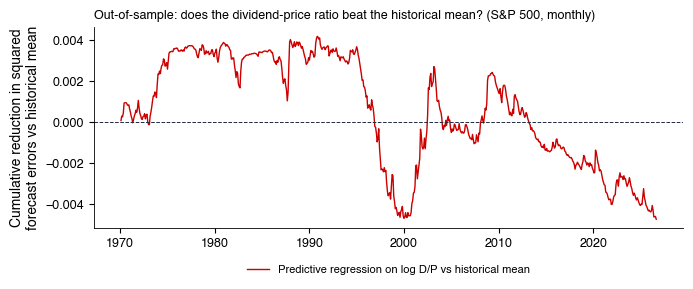

In [21]:
df, attrs = monthly_data()
pr = predictive_regression(df)
show_predictive(pr)
sim = simulate_stambaugh(pr['rho'], pr['corr_uv'], 360)
print(f"Simulation with β = 0, T = 360: mean slope {sim['mean_beta']:.4f}, size of the 5% t-test {sim['size']:.3f}")
o, res = oos_r2(df)
show_oos(res)
fig_oos(o)

In [22]:
for k in ORDER:
    x = rets[k].values
    print(f'{LABELS[k]:26s}', np.round(local_whittle(x, int(len(x) ** 0.65)), 3), np.round(el_autoportmanteau(x), 4))

S&P 500 (US)               [-0.013  0.029] [1.3141e+01 1.0000e+00 3.0000e-04]
Euro Stoxx 50              [-0.031  0.028] [2.4103 1.     0.1205]
Nikkei 225 (Japan)         [-0.002  0.029] [2.4463 1.     0.1178]
Hang Seng (HK)             [-0.009  0.029] [0.0318 1.     0.8585]
BET (Romania)              [0.118 0.029] [1.49216e+01 1.00000e+00 1.00000e-04]
WIG20 (Poland)             [0.    0.029] [1.023  1.     0.3118]
BUX (Hungary)              [0.032 0.029] [2.2971 1.     0.1296]
PX (Czechia)               [0.071 0.029] [2.6827 1.     0.1014]
BIST 100 (Turkey)          [0.052 0.029] [0.0389 1.     0.8436]
Bovespa (Brazil)           [0.042 0.029] [1.3137 1.     0.2517]
IPC (Mexico)               [0.029 0.029] [1.4144e+01 1.0000e+00 2.0000e-04]
Nifty 50 (India)           [0.051 0.029] [3.9176 1.     0.0478]
Shanghai (China)           [0.095 0.029] [1.2216 1.     0.269 ]
Bitcoin                    [0.063 0.033] [0.7539 1.     0.3853]
Ethereum                   [0.112 0.034] [0.1935 1.     0

In [23]:
show_event(event_study_bank_tax())
for k in ('sp500', 'bet'):
    a = amh_regression(k)
    print(f"{LABELS[k]}: z*(5) on {a['n']} rolling windows (HAC, {a['lags']} lags): volatility slope {a['b_vol']:.3f} (t = {a['t_vol']:.2f}), "
          f"crisis dummy {a['b_crisis']:.2f} (t = {a['t_crisis']:.2f}), R² = {a['r2']:.3f}")
tab, steps = stepm_calendar()
show_steps(steps)
tab.round(4)

Bank-tax event study, 2018-12-19: BET return on day 0 -11.9%, estimation window 240 days
  TLV: AR0 = -8.3% (t = -6.85), CAR[0, +5] = -1.1% (t = -0.48)
  BRD: AR0 = -5.6% (t = -4.03), CAR[0, +5] = -2.6% (t = -1.01)
  equal-weighted portfolio: AR0 = -6.9% (t = -7.03), CAR[0, +5] = -1.9% (t = -1.00)
  residual correlation TLV–BRD 0.15; t of the mean AR0: independence -7.55, portfolio -7.03
  variance of a 10-firm mean AR relative to independence 2.38; Kolari–Pynnönen inflation factor 2.81
S&P 500 (US): z*(5) on 296 rolling windows (HAC, 24 lags): volatility slope 0.006 (t = 0.27), crisis dummy -0.67 (t = -2.37), R² = 0.204
BET (Romania): z*(5) on 294 rolling windows (HAC, 24 lags): volatility slope -0.008 (t = -0.36), crisis dummy -0.82 (t = -2.77), R² = 0.147


StepM critical p-values, step by step: [0.0016, 0.0018]


,market,effect,p,holm_reject,stepm_reject,boot_size5
0,sp500,dow,0.8263,False,False,0.0260
1,sp500,jan,0.4257,False,False,0.0591
2,sp500,tom,0.3539,False,False,0.0330
3,bet,dow,0.3052,False,False,0.0841
4,bet,jan,0.1368,False,False,0.0771
5,bet,tom,0.0003,True,True,0.0701
6,stoxx,dow,0.6319,False,False,0.0551
7,stoxx,jan,0.7738,False,False,0.0631
8,stoxx,tom,0.2266,False,False,0.0741
9,wig20,dow,0.2262,False,False,0.0801
